In [ ]:
import sys
import os
import pandas as pd
import numpy as np

from src.data_loader import load_data
from src.solver_LAM import solve_lam_stqp
from src.solver_Markowitz import solve_markowitz
from src.visualize_portfolio import visualize_portfolio_performance
from src.efficient_frontier import compute_efficient_frontier_parallel, plot_efficient_frontier
from src.calculate_sharpe_ratio import calculate_portfolio_sharpe
from src.efficient_frontier_comparison import compute_efficient_frontier_markowitz, compute_efficient_frontier_lam, plot_efficient_frontier


## **パラメータ設定**

In [ ]:
DATA_FILE = 'data/topix-large500-after.csv'
START_DATE = '2018-01-01'
END_DATE = '2021-12-31'

print("=== Portfolio Optimization (LAM/StQP) ===")
print(f"Target Return: {TARGET_RETURN:.6f}")
print(f"Cardinality K: {CARDINALITY_K}")
print(f"Penalty M: {PENALTY_M}")

=== Portfolio Optimization (LAM/StQP) ===
Target Return: 0.000500
Cardinality K: 10
Penalty M: 1000.0


## **データ読み込み**

In [3]:
# 1. Load Data
mu, sigma, assets, df = load_data(DATA_FILE, start_date=START_DATE, end_date=END_DATE)

Loading data from data/topix-large500-after.csv...
Data loaded successfully. 497 assets.
Optimization period: 2018-01-09 to 2021-12-30 (972 periods)


## **効率的フロンティアの可視化**

Starting parallel efficient frontier (100 points)...
Progress: 100/100 (100.0%)
Finished efficient frontier in 424.79 seconds (parallel).


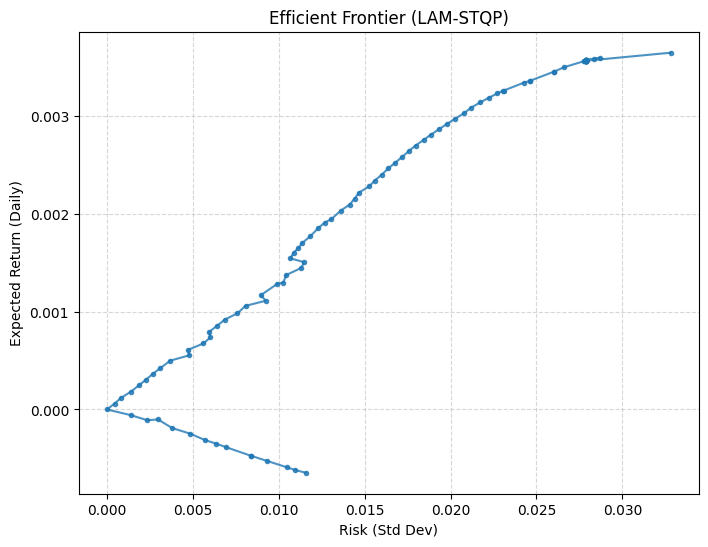

In [4]:
frontier = compute_efficient_frontier_parallel(
        mu, sigma,
        n_points=100,
        k_max=10,
        min_weight=0.01,
        max_weight=1.0,
        penalty_m=1000.0
    )

plot_efficient_frontier(frontier)

In [ ]:
frontier_lam = compute_efficient_frontier_lam(
    mu, sigma,
    n_points=n_points,
    k_max=k_max,
    min_weight=min_weight, max_weight=max_weight,
    penalty_m=penalty_m,
    max_workers=max_workers
)

frontier_mkw = compute_efficient_frontier_markowitz(
    mu, sigma,
    n_points=n_points,
    k_max=k_max,
    min_weight=min_weight, max_weight=max_weight,
    penalty_m=penalty_m,
    max_workers=max_workers
)

# Plot both on same figure
plot_efficient_frontier(frontier_lam, frontier_mkw, title="LAM-STQP vs Markowitz Frontier")

## **最適化問題の求解**
- パラメータ推定期間: 2018-01-01 ~ 2021-12-31

In [ ]:
TARGET_RETURN = 0.0005  # 0.05% daily return (approx 12% annual)
CARDINALITY_K = 10      # Max 10 assets
MIN_WEIGHT = 0.01       # Min 1% per asset
MAX_WEIGHT = 1.0        # Max 100% per asset
PENALTY_M = 1000.0      # Penalty for return deviation

### **LAMモデル**

In [ ]:
result_LAM = solve_lam_stqp(
    mu, sigma, 
    target_return=TARGET_RETURN,
    k_max=CARDINALITY_K,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT,
    penalty_m=PENALTY_M
)

print("\n=== Optimization Results ===")
print(f"Objective Value: {result_LAM['objective']:.6f}")
print(f"Portfolio Return: {result_LAM['return']:.6f}")
print(f"Portfolio Risk (Std): {result_LAM['risk']:.6f}")
print(f"Number of Assets: {len(result_LAM['assets'])}")
print("\nSelected Assets and Weights:")
print(result_LAM['weights'].sort_values(ascending=False))

result_LAM['weights'].to_csv('output_final/optimization_result_LAM.csv', header=['Weight'])
print("\nResults saved to optimization_result_LAM.csv")

### **Markowitzモデル**

In [ ]:
result_Markowitz = solve_markowitz(
    mu, sigma, 
    target_return=TARGET_RETURN,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT
)

print("\n=== Optimization Results ===")
print(f"Objective Value: {result_Markowitz['objective']:.6f}")
print(f"Portfolio Return: {result_Markowitz['return']:.6f}")
print(f"Portfolio Risk (Std): {result_Markowitz['risk']:.6f}")
print(f"Number of Assets: {len(result_Markowitz['assets'])}")
print("\nSelected Assets and Weights:")
print(result_Markowitz['weights'].sort_values(ascending=False))

result_Markowitz['weights'].to_csv('output_final/optimization_result_Markowitz.csv', header=['Weight'])
print("\nResults saved to optimization_result_Markowitz.csv")

## **最適ポートフォリオのパフォーマンス**

### **LAMモデル**

In [ ]:
visualize_portfolio_performance(
    start_date = START_DATE,
    end_date = END_DATE,
    price_csv_path = 'data/topix-large500-after.csv',
    weight_csv_path = 'output_final/optimization_result_LAM.csv',
    output_dir="output_final",
    output_filename="portfolio_performance_LAM.png"
)

### **Markowitzモデル**

In [ ]:
visualize_portfolio_performance(
    start_date = START_DATE,
    end_date = END_DATE,
    price_csv_path = 'data/topix-large500-after.csv',
    weight_csv_path = 'output_final/optimization_result_Markowitz.csv',
    output_dir="output_final",
    output_filename="portfolio_performance_Markowitz.png"
)

## **Sharpe ratioの算出**
- パフォーマンス算出期間: 2018-01-01 ~ 2024-12-31

In [ ]:
WEIGHT_FILE_LAM = "output_final/optimization_result_LAM.csv"
WEIGHT_FILE_MARKOWITZ = "output_final/optimization_result_Markowitz.csv"
START_DATE = "2018-01-01"
END_DATE = "2024-12-31"
risk_free_rate = 0

sharpe_ratio_LAM = calculate_sharpe_ratio(
    weight_file=WEIGHT_FILE_LAM,
    start_date=START_DATE,
    end_date=END_DATE,
    risk_free_rate=risk_free_rate
)

sharpe_ratio_markowitz = calculate_sharpe_ratio(
    weight_file=WEIGHT_FILE_MARKOWITZ,
    start_date=START_DATE,
    end_date=END_DATE,
    risk_free_rate=risk_free_rate
)

print(f"Sharpe Ratio (LAM): {sharpe_ratio_LAM:.6f}")
print(f"Sharpe Ratio (Markowitz): {sharpe_ratio_markowitz:.6f}")
